In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# U1

In [3]:
df_U1_R2 = pd.read_csv('Prediction Results/U1_R2/Results_U1_R2.csv')
df_U1_R4 = pd.read_csv('Prediction Results/U1_R4/Results_U1_R4.csv')
df_U1_R7 = pd.read_csv('Prediction Results/U1_R7/Results_U1_R7.csv')
df_U1_R10 = pd.read_csv('Prediction Results/U1_R10/Results_U1_R10.csv')
df_U1_R12 = pd.read_csv('Prediction Results/U1_R12/Results_U1_R12.csv')

corrugations_u1 = [100, 125, 150, 175, 200]
corrugations_u1 = corrugations_u1[::-1]

sigmas_u1_r2, gammas_u1_r2 = df_U1_R2[['sigma_nm', 'scale_factor_gamma']].to_numpy().T
sigmas_u1_r4, gammas_u1_r4 = df_U1_R4[['sigma_nm', 'scale_factor_gamma']].to_numpy().T
sigmas_u1_r7, gammas_u1_r7 = df_U1_R7[['sigma_nm', 'scale_factor_gamma']].to_numpy().T
sigmas_u1_r10, gammas_u1_r10 = df_U1_R10[['sigma_nm', 'scale_factor_gamma']].to_numpy().T
sigmas_u1_r12, gammas_u1_r12 = df_U1_R12[['sigma_nm', 'scale_factor_gamma']].to_numpy().T


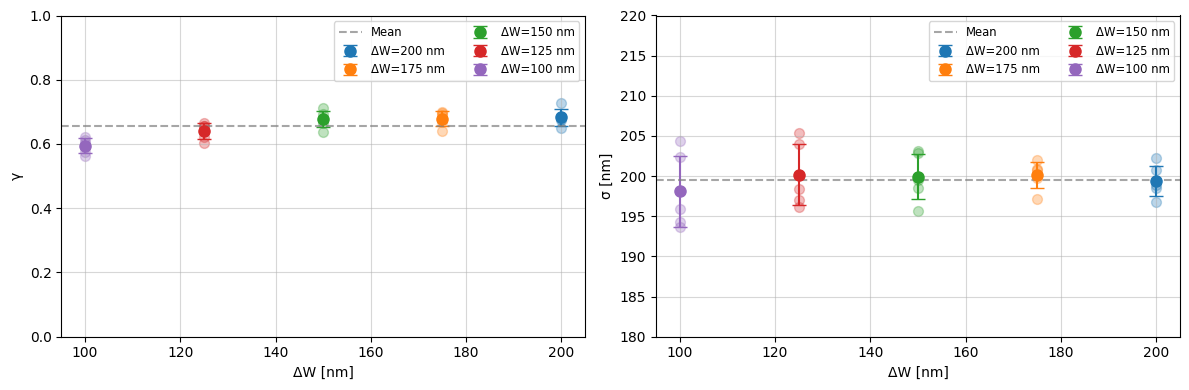

In [4]:
gammas_matrix = np.array([gammas_u1_r2, gammas_u1_r4, gammas_u1_r7, gammas_u1_r10, gammas_u1_r12])
sigmas_matrix = np.array([sigmas_u1_r2, sigmas_u1_r4, sigmas_u1_r7, sigmas_u1_r10, sigmas_u1_r12])

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

for i, corr in enumerate(corrugations_u1):
    values = gammas_matrix[:, i]  
    
    ax[0].scatter([corr] * len(values), values, color=colors[i], alpha=0.3, s=50)
    
    mean = np.mean(values)
    std = np.std(values)
    ax[0].errorbar(corr, mean, yerr=std, fmt='o', color=colors[i], ecolor=colors[i], capsize=5, markersize=8, label=f'ΔW={corr} nm')

mean_gamma = np.mean(gammas_matrix)
ax[0].axhline(mean_gamma, linestyle='--', color='grey', alpha=0.7, label='Mean')

ax[0].set_ylim(0, 1.0)
ax[0].set_xlabel('ΔW [nm]')
ax[0].set_ylabel('γ')
ax[0].grid(True, alpha=0.5)
ax[0].legend(ncols=2, fontsize='small')

for i, corr in enumerate(corrugations_u1):
    values = sigmas_matrix[:, i]  
    
    ax[1].scatter([corr] * len(values), values, color=colors[i], alpha=0.3, s=50)
    
    mean = np.mean(values)
    std = np.std(values)
    ax[1].errorbar(corr, mean, yerr=std, fmt='o', color=colors[i], ecolor=colors[i], capsize=5, markersize=8, label=f'ΔW={corr} nm')

mean_sigma = np.mean(sigmas_matrix)
ax[1].axhline(mean_sigma, linestyle='--', color='grey', alpha=0.7, label='Mean')

ax[1].set_ylim(180, 220)
ax[1].set_xlabel('ΔW [nm]')
ax[1].set_ylabel('σ [nm]')
ax[1].grid(True, alpha=0.5)
ax[1].legend(ncols=2, fontsize='small')

plt.tight_layout()
plt.show()

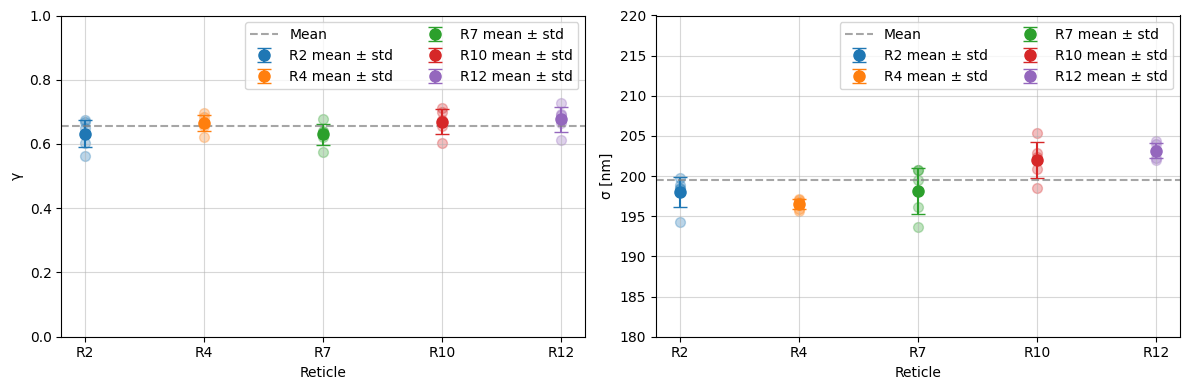

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

gammas_u1 = {
    'R2': (gammas_u1_r2, '#1f77b4'),
    'R4': (gammas_u1_r4, '#ff7f0e'),
    'R7': (gammas_u1_r7, '#2ca02c'),
    'R10': (gammas_u1_r10, '#d62728'),
    'R12': (gammas_u1_r12, '#9467bd')
}

for design, (values, color) in gammas_u1.items():
    ax[0].scatter([design] * len(values), values, color=color, alpha=0.3, s=50)
    
    mean = np.mean(values)
    std = np.std(values)
    ax[0].errorbar(design, mean, yerr=std, fmt='o', color=color, ecolor=color, capsize=5, markersize=8, label=f'{design} mean ± std')

mean_gamma = np.mean(np.concatenate(list(v[0] for v in gammas_u1.values())))
ax[0].axhline(mean_gamma, linestyle='--', color='grey', alpha=0.7, label='Mean')

ax[0].set_ylim(0, 1.0)
ax[0].set_xlabel('Reticle')
ax[0].set_ylabel('γ')
ax[0].grid(True, alpha=0.5)
ax[0].legend(ncols=2)

sigmas_u1 = {
    'R2': (sigmas_u1_r2, '#1f77b4'),
    'R4': (sigmas_u1_r4, '#ff7f0e'),
    'R7': (sigmas_u1_r7, '#2ca02c'),
    'R10': (sigmas_u1_r10, '#d62728'),
    'R12': (sigmas_u1_r12, '#9467bd')
}

for design, (values, color) in sigmas_u1.items():
    ax[1].scatter([design] * len(values), values, color=color, alpha=0.3, s=50)
    
    mean = np.mean(values)
    std = np.std(values)
    ax[1].errorbar(design, mean, yerr=std, fmt='o', color=color, ecolor=color, capsize=5, markersize=8, label=f'{design} mean ± std')

mean_sigma = np.mean(np.concatenate(list(v[0] for v in sigmas_u1.values())))
ax[1].axhline(mean_sigma, linestyle='--', color='grey', alpha=0.7, label='Mean')

ax[1].set_ylim(180, 220)
ax[1].set_xlabel('Reticle')
ax[1].set_ylabel('σ [nm]')
ax[1].grid(True, alpha=0.5)
ax[1].legend(ncols=2)

plt.tight_layout()
plt.show()

# U2

In [6]:
df_U2_R2 = pd.read_csv('Prediction Results/U2_R2/Results_U2_R2.csv')
df_U2_R4 = pd.read_csv('Prediction Results/U2_R4/Results_U2_R4.csv')
df_U2_R7 = pd.read_csv('Prediction Results/U2_R7/Results_U2_R7.csv')
df_U2_R10 = pd.read_csv('Prediction Results/U2_R10/Results_U2_R10.csv')
df_U2_R12 = pd.read_csv('Prediction Results/U2_R12/Results_U2_R12.csv')

corrugations_u2 = [75, 100, 125, 150]
corrugations_u2 = corrugations_u2[::-1]

sigmas_u2_r2, gammas_u2_r2 = df_U2_R2[['sigma_nm', 'scale_factor_gamma']].to_numpy().T
sigmas_u2_r4, gammas_u2_r4 = df_U2_R4[['sigma_nm', 'scale_factor_gamma']].to_numpy().T
sigmas_u2_r7, gammas_u2_r7 = df_U2_R7[['sigma_nm', 'scale_factor_gamma']].to_numpy().T
sigmas_u2_r10, gammas_u2_r10 = df_U2_R10[['sigma_nm', 'scale_factor_gamma']].to_numpy().T
sigmas_u2_r12, gammas_u2_r12 = df_U2_R12[['sigma_nm', 'scale_factor_gamma']].to_numpy().T

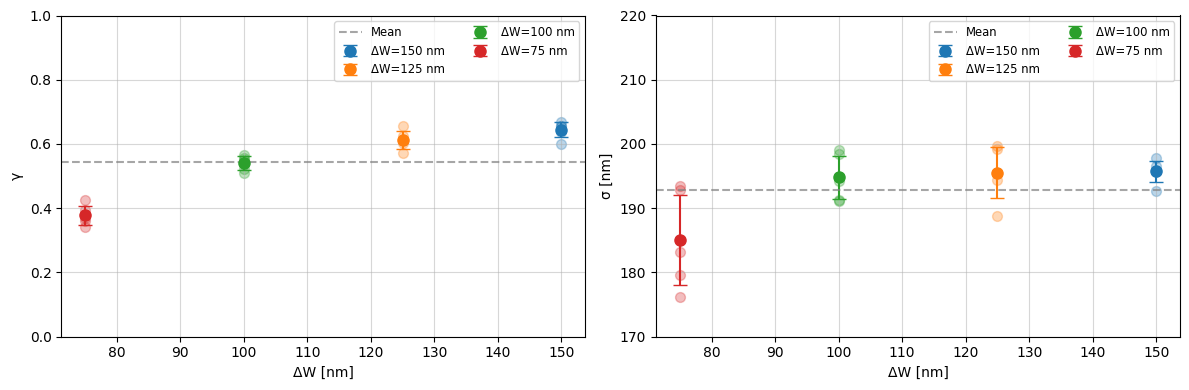

In [7]:
gammas_matrix = np.array([gammas_u2_r2, gammas_u2_r4, gammas_u2_r7, gammas_u2_r10, gammas_u2_r12])
sigmas_matrix = np.array([sigmas_u2_r2, sigmas_u2_r4, sigmas_u2_r7, sigmas_u2_r10, sigmas_u2_r12])

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

for i, corr in enumerate(corrugations_u2):
    values = gammas_matrix[:, i]  
    
    ax[0].scatter([corr] * len(values), values, color=colors[i], alpha=0.3, s=50)
    
    mean = np.mean(values)
    std = np.std(values)
    ax[0].errorbar(corr, mean, yerr=std, fmt='o', color=colors[i], ecolor=colors[i], capsize=5, markersize=8, label=f'ΔW={corr} nm')

mean_gamma = np.mean(gammas_matrix)
ax[0].axhline(mean_gamma, linestyle='--', color='grey', alpha=0.7, label='Mean')

ax[0].set_ylim(0, 1.0)
ax[0].set_xlabel('ΔW [nm]')
ax[0].set_ylabel('γ')
ax[0].grid(True, alpha=0.5)
ax[0].legend(ncols=2, fontsize='small')

for i, corr in enumerate(corrugations_u2):
    values = sigmas_matrix[:, i]  
    
    ax[1].scatter([corr] * len(values), values, color=colors[i], alpha=0.3, s=50)
    
    mean = np.mean(values)
    std = np.std(values)
    ax[1].errorbar(corr, mean, yerr=std, fmt='o', color=colors[i], ecolor=colors[i], capsize=5, markersize=8, label=f'ΔW={corr} nm')

mean_sigma = np.mean(sigmas_matrix)
ax[1].axhline(mean_sigma, linestyle='--', color='grey', alpha=0.7, label='Mean')

ax[1].set_ylim(170, 220)
ax[1].set_xlabel('ΔW [nm]')
ax[1].set_ylabel('σ [nm]')
ax[1].grid(True, alpha=0.5)
ax[1].legend(ncols=2, fontsize='small')

plt.tight_layout()
plt.show()

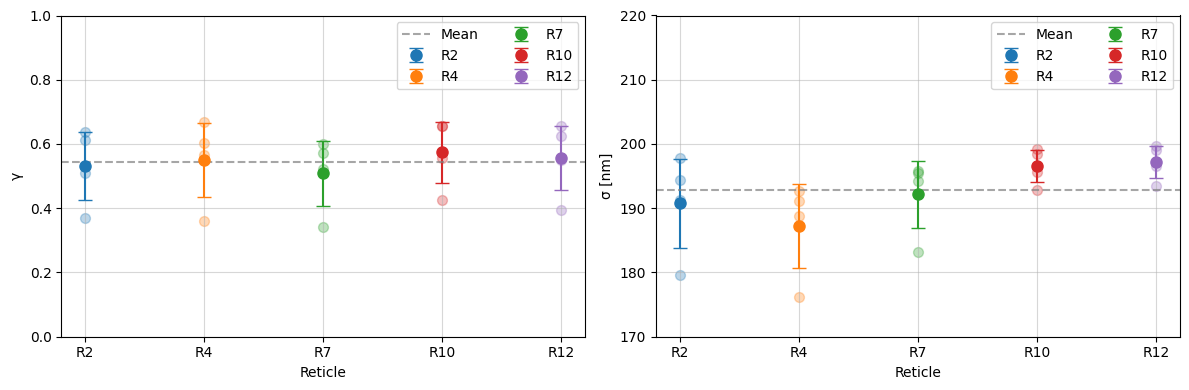

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

gammas_u2 = {
    'R2': (gammas_u2_r2, '#1f77b4'),
    'R4': (gammas_u2_r4, '#ff7f0e'),
    'R7': (gammas_u2_r7, '#2ca02c'),
    'R10': (gammas_u2_r10, '#d62728'),
    'R12': (gammas_u2_r12, '#9467bd')
}

for design, (values, color) in gammas_u2.items():
    ax[0].scatter([design] * len(values), values, color=color, alpha=0.3, s=50)
    
    mean = np.mean(values)
    std = np.std(values)
    ax[0].errorbar(design, mean, yerr=std, fmt='o', color=color, ecolor=color, capsize=5, markersize=8, label=f'{design}')

mean_gamma = np.mean(np.concatenate(list(v[0] for v in gammas_u2.values())))
ax[0].axhline(mean_gamma, linestyle='--', color='grey', alpha=0.7, label='Mean')

ax[0].set_ylim(0, 1.0)
ax[0].set_xlabel('Reticle')
ax[0].set_ylabel('γ')
ax[0].grid(True, alpha=0.5)
ax[0].legend(ncols=2)

sigmas_u2 = {
    'R2': (sigmas_u2_r2, '#1f77b4'),
    'R4': (sigmas_u2_r4, '#ff7f0e'),
    'R7': (sigmas_u2_r7, '#2ca02c'),
    'R10': (sigmas_u2_r10, '#d62728'),
    'R12': (sigmas_u2_r12, '#9467bd')
}

for design, (values, color) in sigmas_u2.items():
    ax[1].scatter([design] * len(values), values, color=color, alpha=0.3, s=50)
    
    mean = np.mean(values)
    std = np.std(values)
    ax[1].errorbar(design, mean, yerr=std, fmt='o', color=color, ecolor=color, capsize=5, markersize=8, label=f'{design}')

mean_sigma = np.mean(np.concatenate(list(v[0] for v in sigmas_u2.values())))
ax[1].axhline(mean_sigma, linestyle='--', color='grey', alpha=0.7, label='Mean')

ax[1].set_ylim(170, 220)
ax[1].set_xlabel('Reticle')
ax[1].set_ylabel('σ [nm]')
ax[1].grid(True, alpha=0.5)
ax[1].legend(ncols=2)

plt.tight_layout()
plt.show()

# U3

In [9]:
df_U3_R2 = pd.read_csv('Prediction Results/U3_R2/Results_U3_R2.csv')
df_U3_R4 = pd.read_csv('Prediction Results/U3_R4/Results_U3_R4.csv')
df_U3_R7 = pd.read_csv('Prediction Results/U3_R7/Results_U3_R7.csv')
df_U3_R10 = pd.read_csv('Prediction Results/U3_R10/Results_U3_R10.csv')
df_U3_R12 = pd.read_csv('Prediction Results/U3_R12/Results_U3_R12.csv')

corrugations_u3 = [100, 125]
corrugations_u3 = corrugations_u3[::-1]

sigmas_u3_r2, gammas_u3_r2 = df_U3_R2[['sigma_nm', 'scale_factor_gamma']].to_numpy().T
sigmas_u3_r4, gammas_u3_r4 = df_U3_R4[['sigma_nm', 'scale_factor_gamma']].to_numpy().T
sigmas_u3_r7, gammas_u3_r7 = df_U3_R7[['sigma_nm', 'scale_factor_gamma']].to_numpy().T
sigmas_u3_r10, gammas_u3_r10 = df_U3_R10[['sigma_nm', 'scale_factor_gamma']].to_numpy().T
sigmas_u3_r12, gammas_u3_r12 = df_U3_R12[['sigma_nm', 'scale_factor_gamma']].to_numpy().T

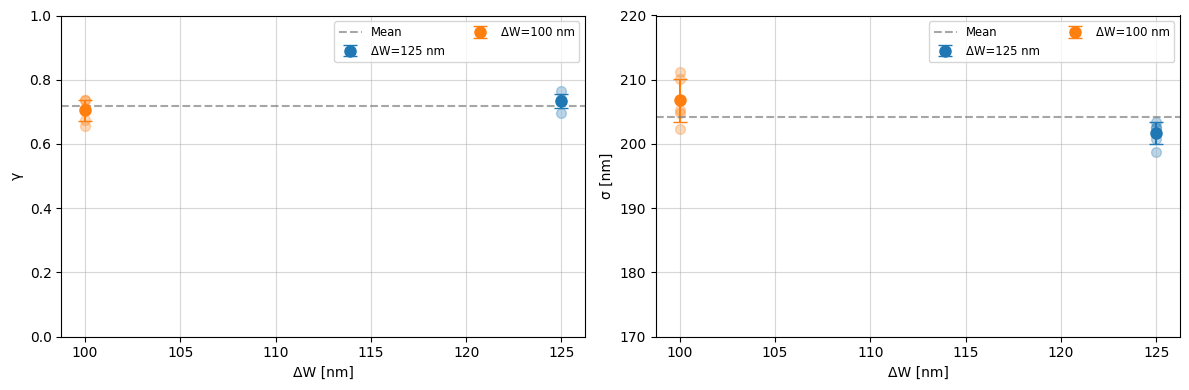

In [10]:
gammas_matrix = np.array([gammas_u3_r2, gammas_u3_r4, gammas_u3_r7, gammas_u3_r10, gammas_u3_r12])
sigmas_matrix = np.array([sigmas_u3_r2, sigmas_u3_r4, sigmas_u3_r7, sigmas_u3_r10, sigmas_u3_r12])

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

for i, corr in enumerate(corrugations_u3):
    values = gammas_matrix[:, i]  
    
    ax[0].scatter([corr] * len(values), values, color=colors[i], alpha=0.3, s=50)
    
    mean = np.mean(values)
    std = np.std(values)
    ax[0].errorbar(corr, mean, yerr=std, fmt='o', color=colors[i], ecolor=colors[i], capsize=5, markersize=8, label=f'ΔW={corr} nm')

mean_gamma = np.mean(gammas_matrix)
ax[0].axhline(mean_gamma, linestyle='--', color='grey', alpha=0.7, label='Mean')

ax[0].set_ylim(0, 1.0)
ax[0].set_xlabel('ΔW [nm]')
ax[0].set_ylabel('γ')
ax[0].grid(True, alpha=0.5)
ax[0].legend(ncols=2, fontsize='small')

for i, corr in enumerate(corrugations_u3):
    values = sigmas_matrix[:, i]  
    
    ax[1].scatter([corr] * len(values), values, color=colors[i], alpha=0.3, s=50)
    
    mean = np.mean(values)
    std = np.std(values)
    ax[1].errorbar(corr, mean, yerr=std, fmt='o', color=colors[i], ecolor=colors[i], capsize=5, markersize=8, label=f'ΔW={corr} nm')

mean_sigma = np.mean(sigmas_matrix)
ax[1].axhline(mean_sigma, linestyle='--', color='grey', alpha=0.7, label='Mean')

ax[1].set_ylim(170, 220)
ax[1].set_xlabel('ΔW [nm]')
ax[1].set_ylabel('σ [nm]')
ax[1].grid(True, alpha=0.5)
ax[1].legend(ncols=2, fontsize='small')

plt.tight_layout()
plt.show()

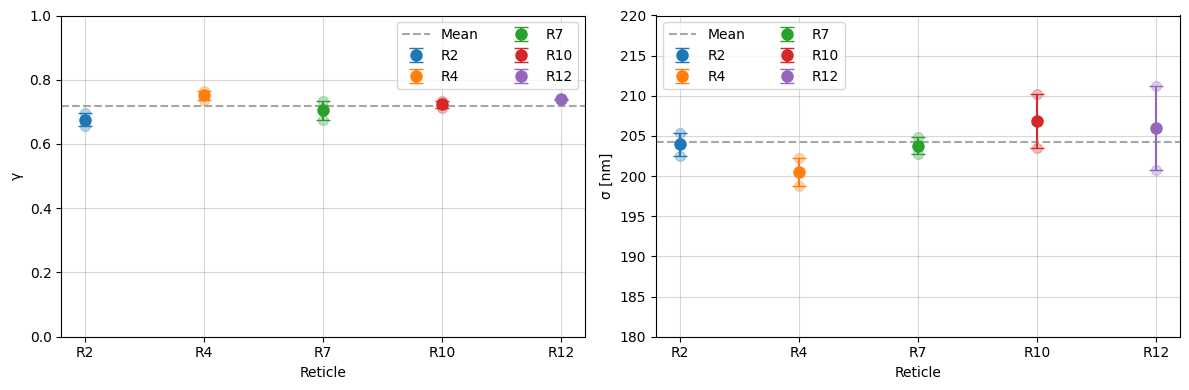

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

gammas_u3 = {
    'R2': (gammas_u3_r2, '#1f77b4'),
    'R4': (gammas_u3_r4, '#ff7f0e'),
    'R7': (gammas_u3_r7, '#2ca02c'),
    'R10': (gammas_u3_r10, '#d62728'),
    'R12': (gammas_u3_r12, '#9467bd')
}

for design, (values, color) in gammas_u3.items():
    ax[0].scatter([design] * len(values), values, color=color, alpha=0.3, s=50)
    
    mean = np.mean(values)
    std = np.std(values)
    ax[0].errorbar(design, mean, yerr=std, fmt='o', color=color, ecolor=color, capsize=5, markersize=8, label=f'{design}')

mean_gamma = np.mean(np.concatenate(list(v[0] for v in gammas_u3.values())))
ax[0].axhline(mean_gamma, linestyle='--', color='grey', alpha=0.7, label='Mean')

ax[0].set_ylim(0, 1.0)
ax[0].set_xlabel('Reticle')
ax[0].set_ylabel('γ')
ax[0].grid(True, alpha=0.5)
ax[0].legend(ncols=2)

sigmas_u3 = {
    'R2': (sigmas_u3_r2, '#1f77b4'),
    'R4': (sigmas_u3_r4, '#ff7f0e'),
    'R7': (sigmas_u3_r7, '#2ca02c'),
    'R10': (sigmas_u3_r10, '#d62728'),
    'R12': (sigmas_u3_r12, '#9467bd')
}

for design, (values, color) in sigmas_u3.items():
    ax[1].scatter([design] * len(values), values, color=color, alpha=0.3, s=50)
    
    mean = np.mean(values)
    std = np.std(values)
    ax[1].errorbar(design, mean, yerr=std, fmt='o', color=color, ecolor=color, capsize=5, markersize=8, label=f'{design}')

mean_sigma = np.mean(np.concatenate(list(v[0] for v in sigmas_u3.values())))
ax[1].axhline(mean_sigma, linestyle='--', color='grey', alpha=0.7, label='Mean')

ax[1].set_ylim(180, 220)
ax[1].set_xlabel('Reticle')
ax[1].set_ylabel('σ [nm]')
ax[1].grid(True, alpha=0.5)
ax[1].legend(ncols=2)

plt.tight_layout()
plt.show()

# Overall

R2 0.604 \pm 0.09
R4 0.639 \pm 0.104
R7 0.6 \pm 0.099
R10 0.644 \pm 0.085
R12 0.645 \pm 0.097


<>:16: SyntaxWarning: invalid escape sequence '\p'
<>:16: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_8533/994094042.py:16: SyntaxWarning: invalid escape sequence '\p'
  print(design, np.round(mean, 3), '\pm',np.round(std, 3))


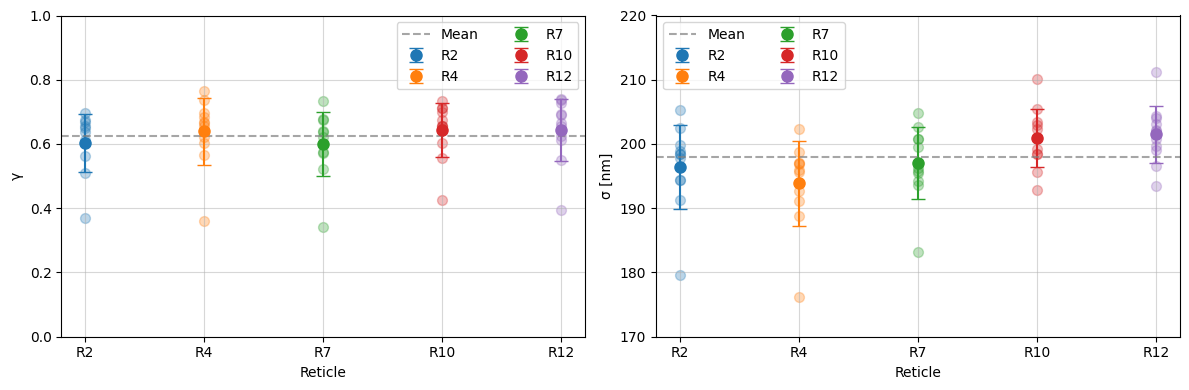

Mean σ = 197.93769440999458 nm 6.295141751820806
Mean γ = 0.6263201692420363 0.0972248541164077


In [20]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

gammas = {
    'R2': (np.concatenate([gammas_u1_r2, gammas_u2_r2, gammas_u3_r2]), '#1f77b4'),
    'R4': (np.concatenate([gammas_u1_r4, gammas_u2_r4, gammas_u3_r4]), '#ff7f0e'),
    'R7': (np.concatenate([gammas_u1_r7, gammas_u2_r7, gammas_u3_r7]), '#2ca02c'),
    'R10': (np.concatenate([gammas_u1_r10, gammas_u2_r10, gammas_u3_r10]), '#d62728'),
    'R12': (np.concatenate([gammas_u1_r12, gammas_u2_r12, gammas_u3_r12]), '#9467bd')
}

for design, (values, color) in gammas.items():
    ax[0].scatter([design] * len(values), values, color=color, alpha=0.3, s=50)
    
    mean = np.mean(values)
    std = np.std(values)
    print(design, np.round(mean, 3), '\pm',np.round(std, 3))
    ax[0].errorbar(design, mean, yerr=std, fmt='o', color=color, ecolor=color, capsize=5, markersize=8, label=f'{design}')

mean_gamma = np.mean(np.concatenate(list(v[0] for v in gammas.values())))
std_gamma = np.std(np.concatenate(list(v[0] for v in gammas.values())))
ax[0].axhline(mean_gamma, linestyle='--', color='grey', alpha=0.7, label='Mean')

ax[0].set_ylim(0, 1.0)
ax[0].set_xlabel('Reticle')
ax[0].set_ylabel('γ')
ax[0].grid(True, alpha=0.5)
ax[0].legend(ncols=2)

sigmas = {
    'R2': (np.concatenate([sigmas_u1_r2, sigmas_u2_r2, sigmas_u3_r2]), '#1f77b4'),
    'R4': (np.concatenate([sigmas_u1_r4, sigmas_u2_r4, sigmas_u3_r4]), '#ff7f0e'),
    'R7': (np.concatenate([sigmas_u1_r7, sigmas_u2_r7, sigmas_u3_r7]), '#2ca02c'),
    'R10': (np.concatenate([sigmas_u1_r10, sigmas_u2_r10, sigmas_u3_r10]), '#d62728'),
    'R12': (np.concatenate([sigmas_u1_r12, sigmas_u2_r12, sigmas_u3_r12]), '#9467bd')
}

for design, (values, color) in sigmas.items():
    ax[1].scatter([design] * len(values), values, color=color, alpha=0.3, s=50)
    
    mean = np.mean(values)
    std = np.std(values)
    #print(f'${design}, {np.round(mean, 2)} \pm {np.round(std, 2)}$')
    ax[1].errorbar(design, mean, yerr=std, fmt='o', color=color, ecolor=color, capsize=5, markersize=8, label=f'{design}')

mean_sigma = np.mean(np.concatenate(list(v[0] for v in sigmas.values())))
std_sigma = np.std(np.concatenate(list(v[0] for v in sigmas.values())))
ax[1].axhline(mean_sigma, linestyle='--', color='grey', alpha=0.7, label='Mean')

ax[1].set_ylim(170, 220)
ax[1].set_xlabel('Reticle')
ax[1].set_ylabel('σ [nm]')
ax[1].grid(True, alpha=0.5)
ax[1].legend(ncols=2)

plt.tight_layout()
plt.show()

print(f'Mean σ = {mean_sigma} nm', std_sigma)
print(f'Mean γ = {mean_gamma}', std_gamma)

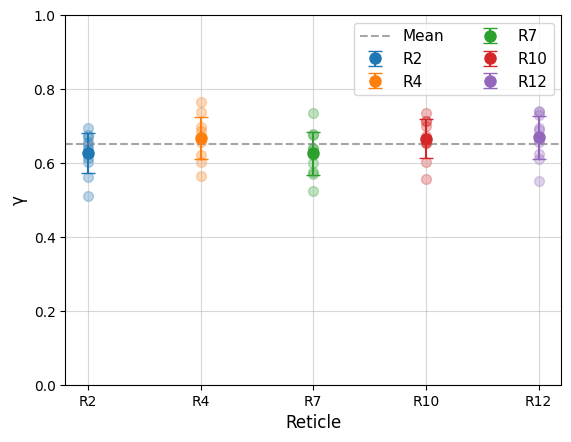

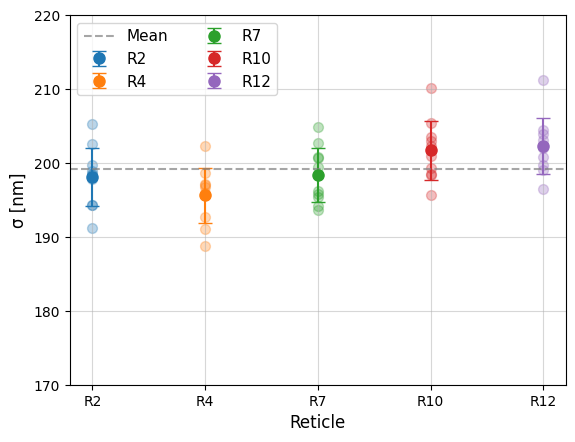

In [14]:
for design, (values, color) in gammas.items():
    plt.scatter([design] * len(values), values, color=color, alpha=0.3, s=50)
    
    mean = np.mean(values)
    std = np.std(values)
    plt.errorbar(design, mean, yerr=std, fmt='o', color=color, ecolor=color, capsize=5, markersize=8, label=f'{design}')

plt.axhline(mean_gamma, linestyle='--', color='grey', alpha=0.7, label='Mean')

plt.ylim(0, 1.0)
plt.xlabel('Reticle', fontsize=12)
plt.ylabel('γ', fontsize=12)
plt.grid(True, alpha=0.5)
plt.legend(ncols=2, fontsize=11)
#plt.savefig("gamma_fit.png", dpi=300, bbox_inches="tight")
plt.show()

for design, (values, color) in sigmas.items():
    plt.scatter([design] * len(values), values, color=color, alpha=0.3, s=50)
    
    mean = np.mean(values)
    std = np.std(values)
    plt.errorbar(design, mean, yerr=std, fmt='o', color=color, ecolor=color, capsize=5, markersize=8, label=f'{design}')

plt.axhline(mean_sigma, linestyle='--', color='grey', alpha=0.7, label='Mean')

plt.ylim(170, 220)
plt.xlabel('Reticle', fontsize=12)
plt.ylabel('σ [nm]', fontsize=12)
plt.grid(True, alpha=0.5)
plt.legend(ncols=2, fontsize=11)
#plt.savefig("sigma_fit.png", dpi=300, bbox_inches="tight")
plt.show()

## No U2

<>:42: SyntaxWarning: invalid escape sequence '\p'
<>:42: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_8533/617539921.py:42: SyntaxWarning: invalid escape sequence '\p'
  print(f'${design}, {np.round(mean, 2)} \pm {np.round(std, 2)}$')


$R2, 199.69 \pm 3.22$
$R4, 197.65 \pm 2.12$
$R7, 199.76 \pm 3.52$
$R10, 203.39 \pm 3.41$
$R12, 203.98 \pm 3.18$


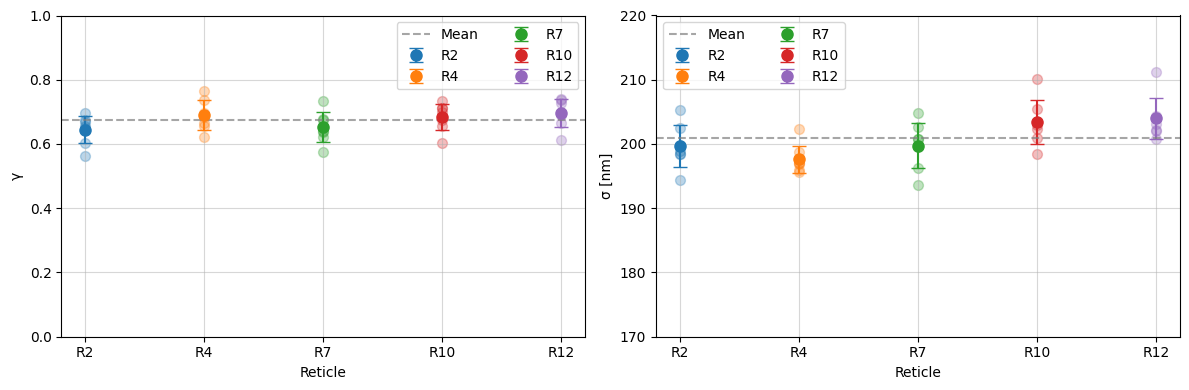

Mean σ = 200.89191310883467 nm 3.9496688960636734
Mean γ = 0.6733155083507364 0.048547216839075896


In [24]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

gammas = {
    'R2': (np.concatenate([gammas_u1_r2, gammas_u3_r2]), '#1f77b4'),
    'R4': (np.concatenate([gammas_u1_r4, gammas_u3_r4]), '#ff7f0e'),
    'R7': (np.concatenate([gammas_u1_r7, gammas_u3_r7]), '#2ca02c'),
    'R10': (np.concatenate([gammas_u1_r10, gammas_u3_r10]), '#d62728'),
    'R12': (np.concatenate([gammas_u1_r12, gammas_u3_r12]), '#9467bd')
}

for design, (values, color) in gammas.items():
    ax[0].scatter([design] * len(values), values, color=color, alpha=0.3, s=50)
    
    mean = np.mean(values)
    std = np.std(values)
    #print(design, np.round(mean, 3), '\pm',np.round(std, 3))
    ax[0].errorbar(design, mean, yerr=std, fmt='o', color=color, ecolor=color, capsize=5, markersize=8, label=f'{design}')

mean_gamma = np.mean(np.concatenate(list(v[0] for v in gammas.values())))
std_gamma = np.std(np.concatenate(list(v[0] for v in gammas.values())))
ax[0].axhline(mean_gamma, linestyle='--', color='grey', alpha=0.7, label='Mean')

ax[0].set_ylim(0, 1.0)
ax[0].set_xlabel('Reticle')
ax[0].set_ylabel('γ')
ax[0].grid(True, alpha=0.5)
ax[0].legend(ncols=2)

sigmas = {
    'R2': (np.concatenate([sigmas_u1_r2, sigmas_u3_r2]), '#1f77b4'),
    'R4': (np.concatenate([sigmas_u1_r4, sigmas_u3_r4]), '#ff7f0e'),
    'R7': (np.concatenate([sigmas_u1_r7, sigmas_u3_r7]), '#2ca02c'),
    'R10': (np.concatenate([sigmas_u1_r10, sigmas_u3_r10]), '#d62728'),
    'R12': (np.concatenate([sigmas_u1_r12, sigmas_u3_r12]), '#9467bd')
}

for design, (values, color) in sigmas.items():
    ax[1].scatter([design] * len(values), values, color=color, alpha=0.3, s=50)
    
    mean = np.mean(values)
    std = np.std(values)
    print(f'${design}, {np.round(mean, 2)} \pm {np.round(std, 2)}$')
    ax[1].errorbar(design, mean, yerr=std, fmt='o', color=color, ecolor=color, capsize=5, markersize=8, label=f'{design}')

mean_sigma = np.mean(np.concatenate(list(v[0] for v in sigmas.values())))
std_sigma = np.std(np.concatenate(list(v[0] for v in sigmas.values())))
ax[1].axhline(mean_sigma, linestyle='--', color='grey', alpha=0.7, label='Mean')

ax[1].set_ylim(170, 220)
ax[1].set_xlabel('Reticle')
ax[1].set_ylabel('σ [nm]')
ax[1].grid(True, alpha=0.5)
ax[1].legend(ncols=2)

plt.tight_layout()
plt.show()

print(f'Mean σ = {mean_sigma} nm', std_sigma)
print(f'Mean γ = {mean_gamma}', std_gamma)

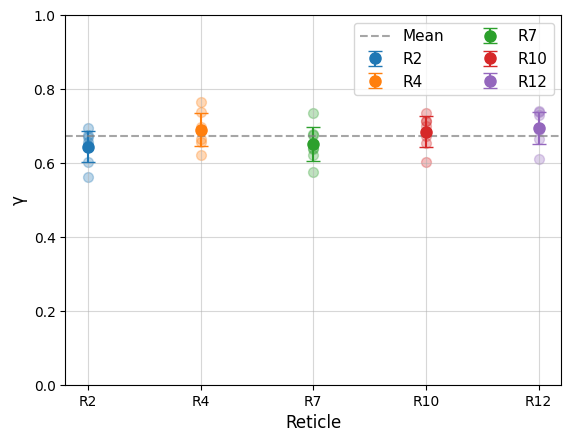

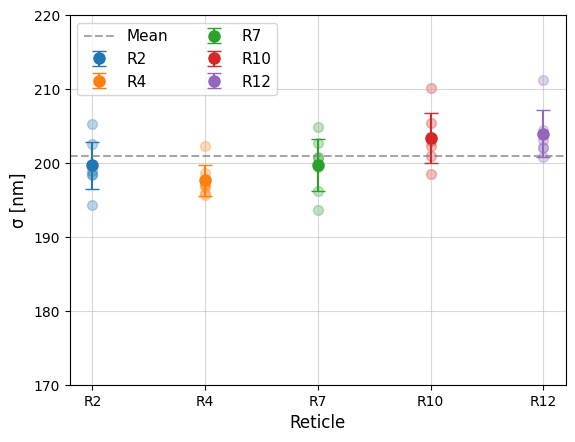

In [ ]:
for design, (values, color) in gammas.items():
    plt.scatter([design] * len(values), values, color=color, alpha=0.3, s=50)
    
    mean = np.mean(values)
    std = np.std(values)
    plt.errorbar(design, mean, yerr=std, fmt='o', color=color, ecolor=color, capsize=5, markersize=8, label=f'{design}')

plt.axhline(mean_gamma, linestyle='--', color='grey', alpha=0.7, label='Mean')

plt.ylim(0, 1.0)
plt.xlabel('Reticle', fontsize=12)
plt.ylabel('γ', fontsize=12)
plt.grid(True, alpha=0.5)
plt.legend(ncols=2, fontsize=11)
#plt.savefig("gamma_fit_no_U2.png", dpi=300, bbox_inches="tight")
plt.show()

for design, (values, color) in sigmas.items():
    plt.scatter([design] * len(values), values, color=color, alpha=0.3, s=50)
    
    mean = np.mean(values)
    std = np.std(values)
    plt.errorbar(design, mean, yerr=std, fmt='o', color=color, ecolor=color, capsize=5, markersize=8, label=f'{design}')

plt.axhline(mean_sigma, linestyle='--', color='grey', alpha=0.7, label='Mean')

plt.ylim(170, 220)
plt.xlabel('Reticle', fontsize=12)
plt.ylabel('σ [nm]', fontsize=12)
plt.grid(True, alpha=0.5)
plt.legend(ncols=2, fontsize=11)
#plt.savefig("sigma_fit_no_U2.png", dpi=300, bbox_inches="tight")
plt.show()